# Рынок квартир Санкт-Петербурга по данным CIAN — 2026
1. Как распределены цены и цена за м²?
2. Какую долю предложения покрывают разные бюджеты?
3. Как доступность зависит от числа комнат?
4. Как отличаются районы по медианной цене и цене за м²?
5. Какой бюджет нужен для покрытия 25%, 50%, 75% и 90% наблюдаемого предложения?

## 1. Импорт библиотек

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
})

## 2. Загрузка подготовленного снапшота

In [2]:
DATA_PATH = Path("../data/processed/cian_spb_sale_clean.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Нет data/processed/cian_spb_sale_clean.csv. "
        "Сначала запустите scripts/prepare_data.py"
    )

flats = pd.read_csv(DATA_PATH)

if "collected_at" in flats.columns:
    flats["collected_at"] = pd.to_datetime(flats["collected_at"], errors="coerce", utc=True)

print(f"Объявлений: {len(flats):,}".replace(",", " "))
if "collected_at" in flats.columns and flats["collected_at"].notna().any():
    print("Снимок:", flats["collected_at"].max())

flats.head()

Объявлений: 2 871
Снимок: 2026-10-01 19:44:31+00:00


,offer_id,collected_at,url,rooms,price,price_mln,total_meters,price_per_m2,district,underground,floor,floors_count,residential_complex,author_type,location,deal_type,accommodation_type,author,rooms_count,street,house_number,requested_segment
0,327096120,2026-10-01 19:44:31+00:00,https://spb.cian.ru/sale/flat/327096120/?conte...,0,13910002,13.91,21.40,"650,000.09",Московский,Московские ворота,7,11,NaN,unknown,Санкт-Петербург,sale,flat,ELEMENT,1,Коли Томчака,3,studio
1,333578417,2026-10-01 19:44:31+00:00,https://spb.cian.ru/sale/flat/333578417/?conte...,0,3200000,3.20,12.00,"266,666.67",Приморский,Черная речка,1,5,NaN,unknown,Санкт-Петербург,sale,flat,Вторичка Групп,1,Сестрорецкая,3,studio
2,333728979,2026-10-01 19:44:31+00:00,https://spb.cian.ru/sale/flat/333728979/?conte...,0,5950000,5.95,23.00,"258,695.65",Василеостровский,Приморская,10,16,NaN,unknown,Санкт-Петербург,sale,flat,Экотон,1,Наличная,51,studio
3,326074488,2026-10-01 19:44:31+00:00,https://spb.cian.ru/sale/flat/326074488/?conte...,0,14601950,14.60,21.01,"695,000.00",Центральный,Площадь Восстания,3,10,NaN,unknown,Санкт-Петербург,sale,flat,Балтийская коммерция,1,Новгородская,14,studio
4,329556790,2026-10-01 19:44:31+00:00,https://spb.cian.ru/sale/flat/329556790/?conte...,0,9800000,9.80,19.70,"497,461.93",Адмиралтейский,Балтийская,8,11,NaN,unknown,Санкт-Петербург,sale,flat,Этажи Санкт-Петербург,1,бульвар Измайловский,1к2,studio


## 3. Проверка качества данных

In [3]:
summary_cols = [
    c for c in [
        "price", "price_mln", "price_per_m2", "total_meters",
        "rooms", "floor", "floors_count"
    ] if c in flats.columns
]

display(flats[summary_cols].describe(percentiles=[.25, .5, .75, .9, .95]).T)

missing = (
    flats.isna().mean().mul(100)
    .sort_values(ascending=False)
    .rename("missing_pct")
    .to_frame()
)
display(missing.head(15))

,count,mean,std,min,25%,50%,75%,90%,95%,max
price,"2,871.00","23,014,472.75","38,071,185.47","2,150,000.00","7,789,876.00","11,499,000.00","22,000,000.00","45,890,000.00","75,000,000.00","560,000,000.00"
price_mln,"2,871.00",23.01,38.07,2.15,7.79,11.50,22.00,45.89,75.00,560.00
price_per_m2,"2,871.00","381,810.57","197,648.53","71,299.64","256,756.76","328,592.81","450,000.00","613,953.49","745,680.09","2,527,173.91"
total_meters,"2,871.00",51.86,44.67,10.00,24.70,34.70,63.54,101.00,139.65,442.00
rooms,"2,871.00",1.13,1.36,-1.00,0.00,1.00,2.00,3.00,4.00,5.00
floor,"2,871.00",6.62,5.18,1.00,3.00,5.00,9.00,14.00,18.00,26.00
floors_count,"2,871.00",12.14,6.52,1.00,7.00,11.00,16.00,23.00,25.00,37.00


,missing_pct
residential_complex,100.00
house_number,30.06
street,12.50
offer_id,0.00
collected_at,0.00
rooms_count,0.00
author,0.00
accommodation_type,0.00
deal_type,0.00
location,0.00


## 4. Структура предложения по числу комнат

In [4]:
room_labels = {
    0: "студия",
    1: "1 комната",
    2: "2 комнаты",
    3: "3 комнаты",
    4: "4 комнаты",
    5: "5 комнат",
}

rooms = flats.dropna(subset=["rooms"]).copy()
rooms["rooms_label"] = rooms["rooms"].map(room_labels).fillna(rooms["rooms"].astype(str) + " комнат")

room_freq = (
    rooms.groupby(["rooms", "rooms_label"], as_index=False)
    .size()
    .rename(columns={"size": "listings"})
    .sort_values("rooms")
)
room_freq["share_pct"] = room_freq["listings"] / len(rooms) * 100
room_freq

,rooms,rooms_label,listings,share_pct
0,-1,-1 комнат,7,0.24
1,0,студия,1423,49.56
2,1,1 комната,431,15.01
3,2,2 комнаты,447,15.57
4,3,3 комнаты,387,13.48
5,4,4 комнаты,127,4.42
6,5,5 комнат,49,1.71


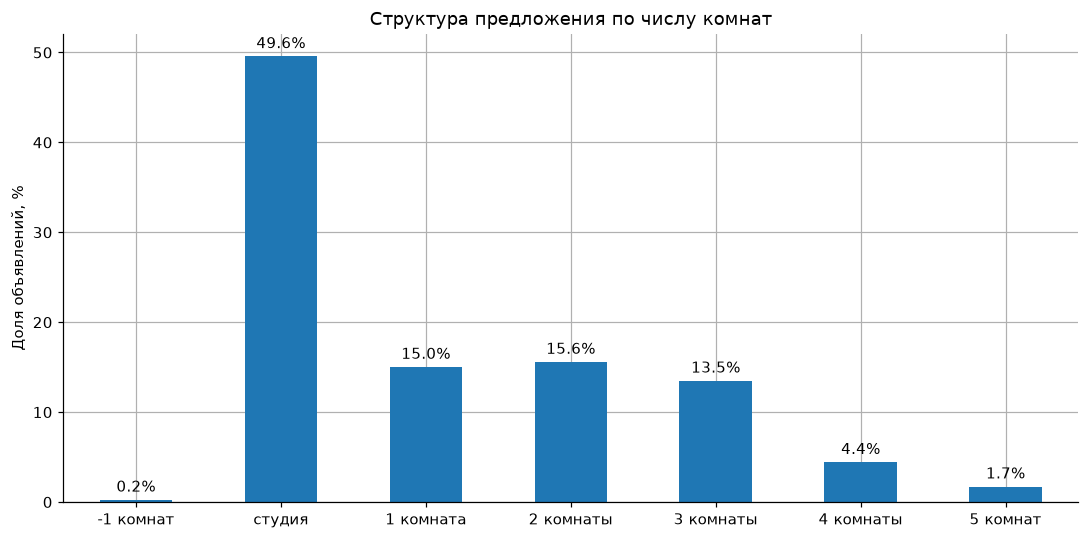

In [5]:
ax = room_freq.plot(x="rooms_label", y="share_pct", kind="bar", legend=False)
ax.set_title("Структура предложения по числу комнат")
ax.set_xlabel("")
ax.set_ylabel("Доля объявлений, %")
ax.tick_params(axis="x", rotation=0)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)
plt.tight_layout()
plt.show()

## 5. Распределение цены и цены за м²

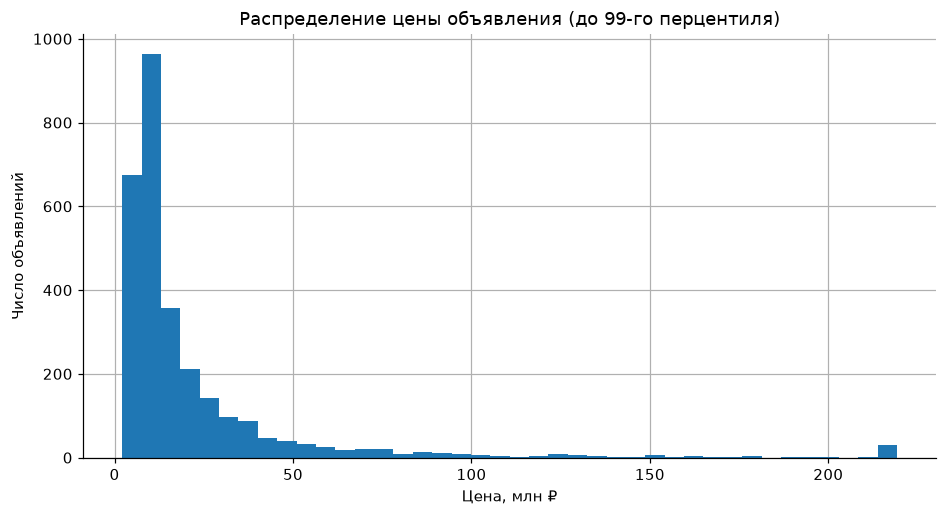

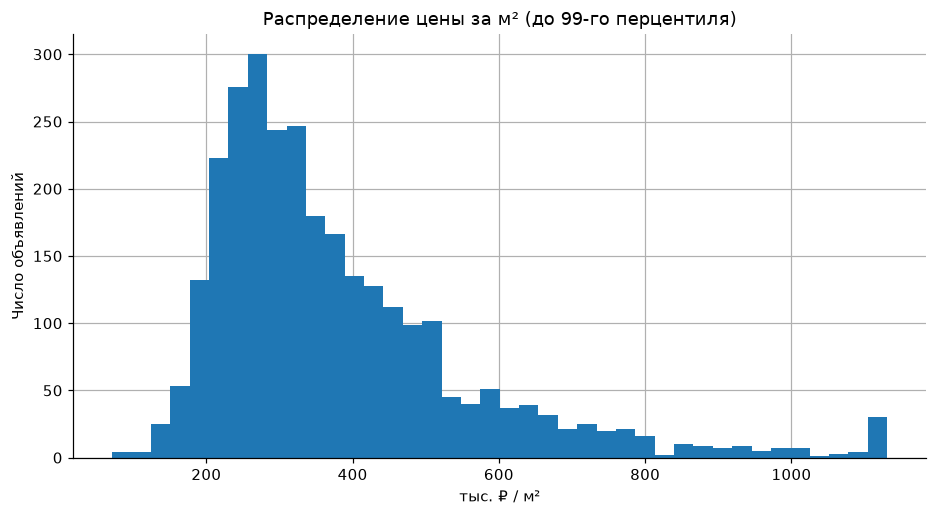

In [6]:
price_p99 = flats["price_mln"].quantile(0.99)

fig, ax = plt.subplots()
ax.hist(flats["price_mln"].clip(upper=price_p99), bins=40)
ax.set_title("Распределение цены объявления (до 99-го перцентиля)")
ax.set_xlabel("Цена, млн ₽")
ax.set_ylabel("Число объявлений")
plt.show()

m2_p99 = flats["price_per_m2"].quantile(0.99)
fig, ax = plt.subplots()
ax.hist(flats["price_per_m2"].clip(upper=m2_p99) / 1000, bins=40)
ax.set_title("Распределение цены за м² (до 99-го перцентиля)")
ax.set_xlabel("тыс. ₽ / м²")
ax.set_ylabel("Число объявлений")
plt.show()

## 6. ECDF: какую долю предложения покрывает заданный бюджет?

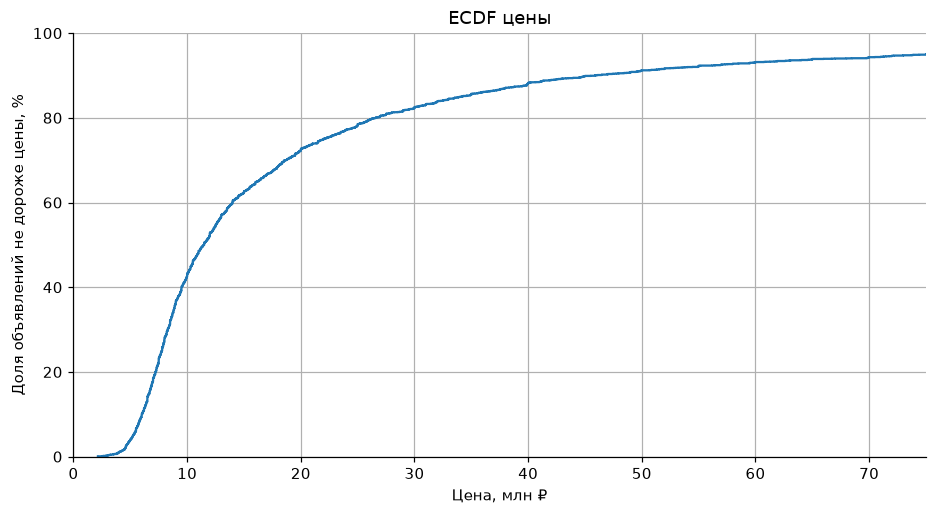

In [7]:
def ecdf(series):
    x = np.sort(series.dropna().to_numpy())
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

x, y = ecdf(flats["price_mln"])

fig, ax = plt.subplots()
ax.step(x, y * 100, where="post")
ax.set_xlim(0, flats["price_mln"].quantile(.95))
ax.set_ylim(0, 100)
ax.set_title("ECDF цены")
ax.set_xlabel("Цена, млн ₽")
ax.set_ylabel("Доля объявлений не дороже цены, %")
plt.show()

In [8]:
budgets = pd.Series([5, 7.5, 10, 15, 20, 30], name="budget_mln")

budget_coverage = pd.DataFrame({
    "budget_mln": budgets,
    "available_listings": [(flats["price_mln"] <= b).sum() for b in budgets],
    "market_share_pct": [(flats["price_mln"] <= b).mean() * 100 for b in budgets],
})
budget_coverage["market_share_pct"] = budget_coverage["market_share_pct"].round(1)
budget_coverage

,budget_mln,available_listings,market_share_pct
0,5.00,117,4.10
1,7.50,667,23.20
2,10.00,1239,43.20
3,15.00,1798,62.60
4,20.00,2085,72.60
5,30.00,2370,82.50


## 7. Доступность по комнатности

In [9]:
BUDGET = 10  # млн ₽ — можно изменить

by_rooms = (
    rooms.assign(affordable=rooms["price_mln"] <= BUDGET)
    .groupby(["rooms", "rooms_label"], as_index=False)
    .agg(
        listings=("price_mln", "size"),
        median_price_mln=("price_mln", "median"),
        median_price_m2=("price_per_m2", "median"),
        affordable_share=("affordable", "mean"),
    )
    .sort_values("rooms")
)
by_rooms["affordable_share_pct"] = by_rooms["affordable_share"] * 100
by_rooms["median_price_m2_thousand"] = by_rooms["median_price_m2"] / 1000

by_rooms[[
    "rooms_label", "listings", "median_price_mln",
    "median_price_m2_thousand", "affordable_share_pct"
]]

,rooms_label,listings,median_price_mln,median_price_m2_thousand,affordable_share_pct
0,-1 комнат,7,10.70,158.77,42.86
1,студия,1423,7.99,319.97,72.10
2,1 комната,431,12.40,328.84,32.95
3,2 комнаты,447,20.20,342.00,10.96
4,3 комнаты,387,28.99,329.29,4.91
5,4 комнаты,127,49.90,413.98,0.00
6,5 комнат,49,80.00,437.96,0.00


In [ ]:
ax = by_rooms.plot(x="rooms_label", y="affordable_share_pct", kind="bar", legend=False)
ax.set_ylim(0, 105)
ax.set_title(f"Доля объявлений до {BUDGET:g} млн ₽ по комнатности")
ax.set_xlabel("")
ax.set_ylabel("Доля, %")
ax.tick_params(axis="x", rotation=0)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)
plt.tight_layout()
plt.show()

## 8. Какой бюджет нужен для покрытия заданной доли предложения?

In [ ]:
targets = [0.25, 0.50, 0.75, 0.90]

required_budget = pd.DataFrame({
    "share_pct": [int(q * 100) for q in targets],
    "budget_mln": [flats["price_mln"].quantile(q) for q in targets],
})
required_budget["budget_mln"] = required_budget["budget_mln"].round(2)
required_budget

## 9. Районы: медианная цена и цена за м²

In [ ]:
if "district" not in flats.columns:
    print("В выгрузке нет поля district.")
else:
    district = flats.copy()
    district["district"] = district["district"].fillna("").str.strip()
    district = district[district["district"].ne("")]

    district_summary = (
        district.groupby("district")
        .agg(
            listings=("price", "size"),
            median_price_mln=("price_mln", "median"),
            median_price_m2=("price_per_m2", "median"),
        )
        .query("listings >= 30")
        .sort_values("median_price_m2", ascending=False)
    )
    district_summary["median_price_m2_thousand"] = district_summary["median_price_m2"] / 1000
    display(district_summary[["listings", "median_price_mln", "median_price_m2_thousand"]])

In [ ]:
if "district" in flats.columns and "district_summary" in globals() and not district_summary.empty:
    plot_data = district_summary.sort_values("median_price_m2_thousand")
    ax = plot_data["median_price_m2_thousand"].plot(kind="barh")
    ax.set_title("Медианная цена за м² по районам (минимум 30 объявлений)")
    ax.set_xlabel("тыс. ₽ / м²")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()

## 10. Ближайшее метро

In [ ]:
if "underground" not in flats.columns:
    print("В выгрузке нет поля underground.")
else:
    metro = flats.copy()
    metro["underground"] = metro["underground"].fillna("").str.strip()
    metro = metro[metro["underground"].ne("")]

    metro_summary = (
        metro.groupby("underground")
        .agg(
            listings=("price", "size"),
            median_price_mln=("price_mln", "median"),
            median_price_m2=("price_per_m2", "median"),
        )
        .query("listings >= 30")
        .sort_values("median_price_m2", ascending=False)
    )
    metro_summary["median_price_m2_thousand"] = metro_summary["median_price_m2"] / 1000
    display(metro_summary[["listings", "median_price_mln", "median_price_m2_thousand"]].head(15))

## 11. Итоговая интерпретация

После запуска notebook сформулируйте выводы по фактическому снапшоту:

- медианная цена квартиры и цена за м²;
- доля предложения, доступная при выбранном бюджете;
- наиболее заметные различия по комнатности;
- районы с наиболее высокой/низкой медианной ценой за м² среди достаточно представленных районов;
- бюджет, соответствующий медиане и 75-му перцентилю.

Здесь лучше не делать вывод о «стоимости всего рынка Санкт-Петербурга»: данные отражают **выборку активных объявлений CIAN на дату сбора**.

## 12. Ограничения

1. Цена объявления может отличаться от фактической цены сделки.
2. Один физический объект может быть представлен несколькими объявлениями.
3. Ограничение числа страниц создаёт выборку из поисковой выдачи; её ранжирование может вносить смещение.
4. Отсутствующие поля зависят от заполненности карточки и качества извлечения.
5. Для динамики рынка одного снапшота недостаточно — нужны регулярные повторные сборы с сохранением `offer_id` и `collected_at`.